Importing libraries

In [1]:
!pip -q install ipywidgets plotly

from google.colab import output
output.enable_custom_widget_manager()
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import ipywidgets as widgets
from IPython.display import display, clear_output
pio.renderers.default = "colab"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 58.4 MB/s eta 0:00:00


Input for users

In [2]:
L = float(input("Beam length (mm): "))
D = float(input("Beam diameter (mm): "))

L, D = L/1000, D/1000  #converting mm to m

if (D/L) > 0.1:
    print(f"WARNING: d/L = {D/L:.4f} > 0.1, not slender!")

r = D/2
I = (np.pi * r**4) / 4

loads = []  #we made an array for storring all the forces (dicrete and continuous both)
while True:
    ans = input("Add a force? (y/n): ")
    if ans.lower() != 'y':
        break

    type = input("Discrete (d) or continuous (c): ")
    if type.lower() == 'd':
        F = float(input("Force(N)(positive means upward force): "))
        x = float(input("Distance from left end(fixed end) (mm): "))
        loads.append({'type': 'd', 'F': F, 'x': x/1000})
    else:
        w = float(input("Load intensity (N/m): "))
        x1 = float(input("Start distance from left end(fixed end) (mm): "))
        x2 = float(input("End distance from left end (mm): "))
        loads.append({'type': 'c', 'w': w, 'x1': x1/1000, 'x2': x2/1000})

if not loads:
    print("No loads applied.")
    exit()

Beam length (mm): 1000
Beam diameter (mm): 50
Add a force? (y/n): y
Discrete (d) or continuous (c): c
Load intensity (N/m): 500
Start distance from left end(fixed end) (mm): 600
End distance from left end (mm): 1000
Add a force? (y/n): n


sfd and bmd

In [3]:
def sfd_bmd(x):
    shear=0
    bending_moment=0

    for load in loads:
        if load["type"]=="d":
            if load["x"]>x:
                shear+=load["F"]
                dist=load["x"]-x
                bending_moment+=load["F"]*dist
        else:
            st=max(load["x1"], x)
            end=load["x2"]
            if end>st:
                length=end-st
                resultant=load["w"]*length
                shear+=resultant
                mid=(st+end)/2
                bending_moment+=resultant*(mid-x)

    return shear,bending_moment

stress

In [4]:
def stress(x,y):
  shear, bending_moment =sfd_bmd(x)
  sigma_x=bending_moment*y/I
  sigma_y=0;
  if abs(y)<r:
    Q=(2/3)*(r**2-y**2)**1.5
    width=2*(r**2-y**2)**0.5

    if width!=0:
      tau_xy=(shear*Q)/(I*width)
    else:
      tau_xy=0;
  else:
    tau_xy=0;

  return sigma_x,sigma_y,tau_xy

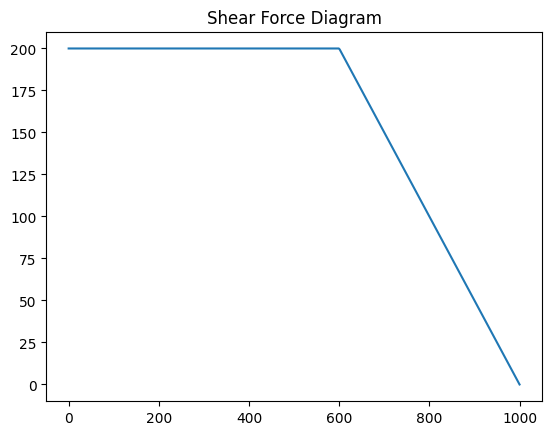

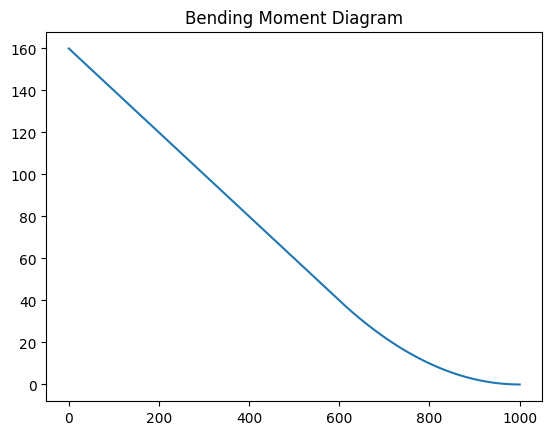

In [5]:
x_vals = np.linspace(0, L, 500)

sfd = []
bmd = []
for x in x_vals:
    s, m = sfd_bmd(x)
    sfd.append(s)
    bmd.append(m)
plt.figure()
plt.plot(x_vals * 1000, sfd)
plt.title("Shear Force Diagram")

plt.figure()
plt.plot(x_vals * 1000, bmd)
plt.title("Bending Moment Diagram")

plt.show()

rotated stress

In [6]:
def rotated(sigma_x,sigma_y,tau_xy,thetha_deg):
  thetha=np.radians(thetha_deg)
  sigma_x_new=((sigma_x+sigma_y)/2 + (sigma_x-sigma_y)/2*np.cos(2*thetha)+ tau_xy*np.sin(2*thetha))
  sigma_y_new=((sigma_x+sigma_y)/2 - (sigma_x-sigma_y)/2*np.cos(2*thetha)- tau_xy*np.sin(2*thetha))
  tau_xy_new=(-(sigma_x-sigma_y)/2*np.sin(2*thetha)+tau_xy*np.cos(2*thetha))

  return sigma_x_new, sigma_y_new, tau_xy_new

Mohr circle

In [7]:
def mohrs(sigma_x,sigma_y,tau_xy):
  centre=(sigma_x+sigma_y)/2
  radius=((((sigma_x-sigma_y)/2)**2 + tau_xy**2))**0.5

  return centre,radius

In [8]:
# Precompute diagrams
x_fine = np.linspace(0.001, L, 400)
sf_arr = np.array([sfd_bmd(x)[0] for x in x_fine]) / 1e3
bm_arr = np.array([sfd_bmd(x)[1] for x in x_fine]) / 1e3

# =========================
# FIGURE BUILDER
# =========================
def make_figure(xv, yv, theta):
    sx, sy, txy = stress(xv, yv)
    sf_v, bm_v = sfd_bmd(xv)
    c, R = mohrs(sx, sy, txy)
    sx2, sy2, txy2 = rotated(sx, sy, txy, theta)

    # Mohr circle
    th = np.linspace(0, 2*np.pi, 250)
    mcx = c/1e6 + R/1e6 * np.cos(th)
    mcy = R/1e6 * np.sin(th)

    # Rotated stress element
    t = np.radians(theta)
    cs, sn = np.cos(t), np.sin(t)
    raw = [(-1,-1), (1,-1), (1,1), (-1,1), (-1,-1)]
    ex = [cs*x - sn*y for x, y in raw]
    ey = [sn*x + cs*y for x, y in raw]

    if abs(theta) > 1:
        ang = np.linspace(0, t, 40)
        arcx = list(1.7 * np.cos(ang))
        arcy = list(1.7 * np.sin(ang))
    else:
        arcx = [1.7]
        arcy = [0]


    info = (
        "<b>STRESS STATE (MPa)</b><br>"
        f"<span style='font-family:monospace'>"
        f"σx  = {sx/1e6:>10.3f}<br>"
        f"σy  = {sy/1e6:>10.3f}<br>"
        f"τxy = {txy/1e6:>10.3f}<br><br>"
        f"<b>ROTATED STATE ({theta:+.0f}°)</b><br>"
        f"σx' = {sx2/1e6:>10.3f}<br>"
        f"σy' = {sy2/1e6:>10.3f}<br>"
        f"τ'  = {txy2/1e6:>10.3f}<br><br>"
        f"<b>MOHR'S CIRCLE</b><br>"
        f"C   = {c/1e6:>10.3f}<br>"
        f"R   = {R/1e6:>10.3f}"
        f"</span>"
    )

    fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        "Side View of Beam", "", "",
        "Mohr's Circle", "Stress Element", "Data Summary"
    ),
    specs=[[{"colspan": 3}, None, None],
           [{}, {}, {}]]
)

    # -----------------------------
    # SIDE VIEW OF BEAM
    # -----------------------------
# Beam (rectangle)
    fig.add_trace(go.Scatter(
      x=[0, L*1000, L*1000, 0, 0],
      y=[-r*1000, -r*1000, r*1000, r*1000, -r*1000],
      fill='toself',
      fillcolor='lightblue',
      line=dict(color='steelblue'),
      mode='lines'
    ), row=1, col=1)

# Fixed support
    fig.add_trace(go.Scatter(
      x=[0, 0],
      y=[-r*2000, r*2000],
      mode='lines',
      line=dict(color='black')
    ), row=1, col=1)

# Moving point
    fig.add_trace(go.Scatter(
      x=[xv*1000],
      y=[yv*1000],
      mode='markers',
      marker=dict(color='cyan', size=10)
    ), row=1, col=1)

    # -----------------------------
    # MOHR'S CIRCLE
    # -----------------------------
    # much tighter window so the circle fills the panel better
    R_mpa = R / 1e6
    c_mpa = c / 1e6

    # Set plotting limits for Mohr's circle
    limit = max(R_mpa, 0.02)

    x_min = c_mpa - limit
    x_max = c_mpa + limit
    y_min = -limit
    y_max = limit

    fig.add_trace(go.Scatter(x=mcx, y=mcy, mode='lines', line=dict(color='blue', width=2)), row=2, col=1)
    fig.add_trace(go.Scatter(x=[c/1e6], y=[0], mode='markers', marker=dict(symbol='cross', color='black')), row=2, col=1)
    fig.add_trace(go.Scatter(x=[sx2/1e6, sy2/1e6], y=[txy2/1e6, -txy2/1e6], mode='lines+markers', line=dict(color='red')), row=2, col=1)
    fig.add_trace(go.Scatter(x=[x_min, x_max], y=[0, 0], mode='lines', line=dict(color='gray', width=1), showlegend=False), row=2, col=1)

    # -----------------------------
    # ROTATED STRESS ELEMENT
    # -----------------------------
    fig.add_trace(go.Scatter(x=ex, y=ey, fill='toself', fillcolor='light blue', line=dict(color='blue', width=2), mode='lines', showlegend=False), row=2, col=2)
    fig.add_trace(go.Scatter(x=arcx, y=arcy, mode='lines', line=dict(color='green', width=2), showlegend=False), row=2, col=2)
    fig.add_trace(go.Scatter(x=[0], y=[0], mode='text', text=[f"σx'={sx2/1e6:.3f}<br>σy'={sy2/1e6:.3f}<br>τ'={txy2/1e6:.3f}"], textfont=dict(color='navy', size=12), showlegend=False), row=2, col=2)
    fig.add_trace(go.Scatter(x=[0, 1.9], y=[0, 0], mode='lines', line=dict(color='gray', dash='dot', width=1), showlegend=False), row=2, col=2)


    fig.add_trace(go.Scatter(x=[0.5], y=[0.55], mode='text', text=[info], textfont=dict(family='monospace', size=16, color='navy'), textposition='middle center', showlegend=False), row=2, col=3)

    # -----------------------------
    # LAYOUT
    # -----------------------------
    fig.update_layout(height=800, width=1200, showlegend=False, plot_bgcolor='white', paper_bgcolor='white', margin=dict(t=80, b=20, l=20, r=20))

    # -----------------------------
    # AXES / ASPECT FIXES
    # -----------------------------
    fig.update_xaxes(title_text="x(mm)", row=1, col=1)
    fig.update_yaxes(title_text="y(mm)", row=1, col=1)

    fig.update_xaxes(range=[x_min, x_max], title_text="σ (MPa)", constrain="domain", row=2, col=1)
    fig.update_yaxes(range=[y_min, y_max], title_text="τ (MPa)", scaleanchor="x5", scaleratio=1, row=2, col=1)

    fig.update_xaxes(range=[-2.5, 2.5], showticklabels=False, showgrid=False, zeroline=False, row=2, col=2)
    fig.update_yaxes(range=[-2.5, 2.5], showticklabels=False, showgrid=False, zeroline=False, scaleanchor="x6", scaleratio=1, row=2, col=2)

    fig.update_xaxes(range=[0, 1], showticklabels=False, showgrid=False, zeroline=False, row=2, col=3)
    fig.update_yaxes(range=[0, 1], showticklabels=False, showgrid=False, zeroline=False, row=2, col=3)

    return fig

# =========================
# WIDGETS
# =========================
sl_x = widgets.FloatSlider(value=0, min=0, max=L*1000, step=0.5, description='x (mm):', style={'description_width': '80px'}, layout=widgets.Layout(width='75%'))
sl_y = widgets.FloatSlider(value=r * 1000 * 0.80, min=-r * 1000, max=r * 1000, step=0.05, description='y (mm):', style={'description_width': '80px'}, layout=widgets.Layout(width='75%'))
sl_t = widgets.FloatSlider(value=0, min=-90, max=90, step=1, description='θ (deg):', style={'description_width': '80px'}, layout=widgets.Layout(width='75%'))

out = widgets.Output()

def update(change=None):
    xv = sl_x.value / 1000
    yv = sl_y.value / 1000
    theta = sl_t.value
    with out:
        clear_output(wait=True)
        fig = make_figure(xv, yv, theta)
        display(fig)

sl_x.observe(update, names='value')
sl_y.observe(update, names='value')
sl_t.observe(update, names='value')

display(widgets.VBox([sl_x, sl_y, sl_t]), out)
update()

Output()

floatslider code(https://ipywidgets.readthedocs.io/en/latest/examples/Widget%20List.html)